# Wikipedia Polls — Descriptive Analysis

## What are polls and why do we use them?

Opinion polls ask a representative sample of voters who they would vote for if the election were held today.
Each poll produces a single data point; by aggregating many polls over time we can track how **public support evolved** throughout the campaign.

For our prediction model, polls are a core signal: they directly measure voter intent and are widely used in election forecasting (e.g. FiveThirtyEight, The Economist models). We include them alongside social media signals (Google Trends, Reddit, Bluesky) to compare how well stated voter intent tracks with online engagement.

## What this notebook does

1. Loads 256 nationwide polls (Jun–Nov 2024) from Bronze
2. Computes 7-day rolling averages to smooth day-to-day noise
3. Annotates charts with key campaign events to identify cause-and-effect patterns
4. Analyses the margin and its direction over time
5. Checks for **pollster bias** — whether certain polling firms systematically over- or under-estimate one candidate

**Input:** `Data/1_Bronze/Polls/wikipedia_polls.csv`

## 0. Setup

In [19]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from house_style import (
    apply_style, styled_fig, style_ax,
    REPUBLICAN, DEMOCRAT, TEXT_PRIMARY, TEXT_MUTED,
    BG_DARK, BG_PANEL, GRID_COLOR, PALETTE
)
apply_style()

BRONZE_PATH  = '../../Data/1_Bronze/Polls/wikipedia_polls.csv'
EVENTS_PATH  = '../../Data/events_2024_election.csv'
print('Setup complete.')

Setup complete.


## 1. Load data

We also load the events CSV so we can annotate all charts with key campaign moments.
Events are filtered to the poll date range so no out-of-range markers appear.

In [20]:
df = pd.read_csv(BRONZE_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

events = pd.read_csv(EVENTS_PATH, parse_dates=['date'])
events = events[(events['date'] >= df['Date'].min()) & (events['date'] <= df['Date'].max())]

print(f'Polls    : {len(df)}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Events   : {len(events)}')
df.head(5)

Polls    : 249
Date range: 2024-07-06 → 2024-11-04
Events   : 27


,Pollster,Date,SampleSize,Trump,Harris,Margin
0,Bendixen & Amandi International (D)[201],2024-07-06,"1,000 (LV)",41.0,42.0,-1.0
1,Emerson College[200],2024-07-08,"1,370 (RV)",49.0,43.0,6.0
2,NBC News[198],2024-07-09,800 (RV),47.0,45.0,2.0
3,ABC News/The Washington Post/Ipsos[199],2024-07-09,"2,041 (RV)",47.0,49.0,-2.0
4,The Economist/YouGov[303],2024-07-09,"1,443 (RV)",42.0,38.0,4.0


## 2. Overview

Before plotting, we look at the basic descriptive statistics.
Key things to check:
- **Mean support** — who leads on average across all polls?
- **Standard deviation** — how much do polls vary? High SD suggests either genuine movement in the race or high pollster variance.
- **Count of leads** — in how many individual polls did each candidate come out ahead?

In [21]:
print(df[['Trump', 'Harris', 'Margin']].describe().round(2))
print(f'\nPolls where Trump leads  : {(df["Margin"] > 0).sum()}')
print(f'Polls where Harris leads : {(df["Margin"] < 0).sum()}')
print(f'Tied polls               : {(df["Margin"] == 0).sum()}')

        Trump  Harris  Margin
count  249.00  249.00  249.00
mean    46.74   48.03   -1.29
std      2.38    2.59    2.96
min     37.00   38.00   -8.00
25%     45.00   47.00   -4.00
50%     47.00   48.00   -1.00
75%     48.00   50.00    1.00
max     53.00   53.00    7.00

Polls where Trump leads  : 76
Polls where Harris leads : 151
Tied polls               : 22


## 3. Polling averages over time

### 3.1 7-day rolling average with event annotations

**Why a rolling average?**
Individual polls have random sampling error (typically ±3 pp). A 7-day rolling average smooths this noise
while still being responsive enough to detect real shifts caused by campaign events.
A longer window (e.g. 30 days) would be too slow; a shorter one would be too noisy.

**What to look for:**
The dotted vertical lines mark key events from our events CSV. When a line coincides with a kink in
the polling trend, it suggests that event moved public opinion. Gaps between lines suggest periods
of campaign stability.

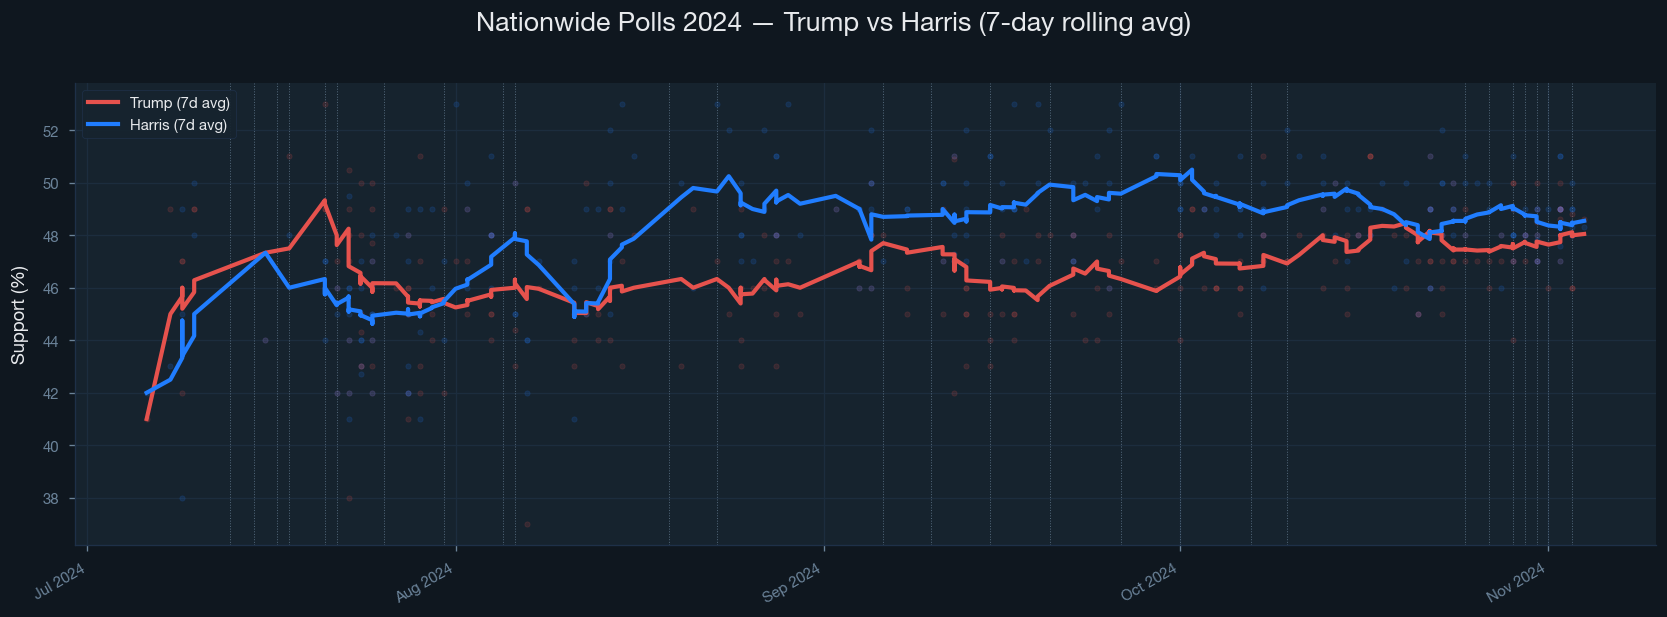

In [22]:
df_plot = df.dropna(subset=['Trump', 'Harris']).set_index('Date').sort_index()
trump_roll  = df_plot['Trump'].rolling('7D',  min_periods=1).mean()
harris_roll = df_plot['Harris'].rolling('7D', min_periods=1).mean()

fig, ax = styled_fig(figsize=(14, 5), title='Nationwide Polls 2024 — Trump vs Harris (7-day rolling avg)')

# Raw scatter (faint) so individual polls are still visible
ax.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.15, s=10, zorder=2)
ax.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.15, s=10, zorder=2)

# Rolling average lines
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label='Trump (7d avg)',  zorder=3)
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label='Harris (7d avg)', zorder=3)

# Event annotations
for _, row in events.iterrows():
    ax.axvline(row['date'], color=TEXT_MUTED, linewidth=0.6, linestyle=':', alpha=0.7, zorder=1)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax, ylabel='Support (%)', grid_axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**What we see:**
- The early polls (Jun–Jul) still show the **Biden era** — Trump was consistently ahead when Biden was the Democratic candidate.
- When Biden withdrew on July 21 and Harris entered the race, her numbers jumped sharply — the so-called **Harris bump**. This is one of the clearest event-driven shifts in the entire dataset.
- From August onward the race tightened. Harris held a small but consistent polling lead through most of September and October.
- The **September 10 debate** produced a visible shift: Harris's rolling average rose slightly in the following week.
- In the final weeks of October, Trump's numbers crept back up, narrowing the gap going into election day.

### 3.2 Trump–Harris margin over time

The margin chart (Trump − Harris) makes the direction and size of the lead immediately visible.
Red fill = Trump ahead, blue fill = Harris ahead.
The baseline (0) is the tie line.

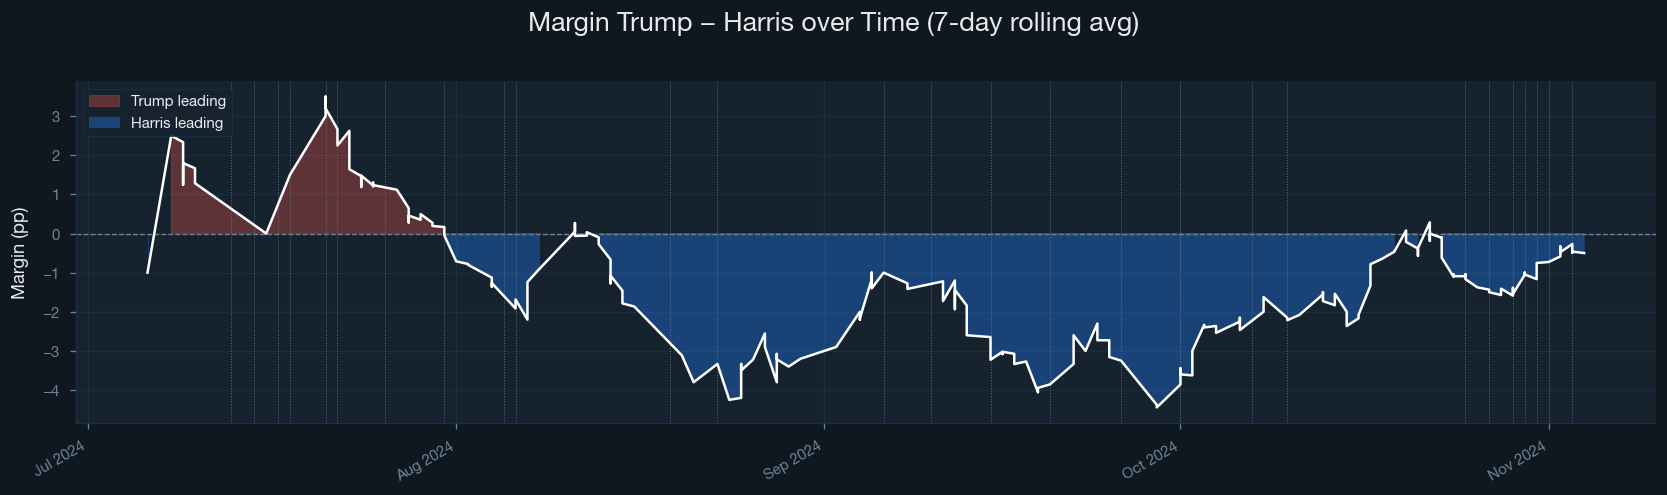

In [23]:
margin_roll = trump_roll - harris_roll

fig, ax = styled_fig(figsize=(14, 4), title='Margin Trump − Harris over Time (7-day rolling avg)')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll >= 0), color=REPUBLICAN, alpha=0.35, label='Trump leading')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll <  0), color=DEMOCRAT,   alpha=0.35, label='Harris leading')
ax.plot(margin_roll, color='white', linewidth=1.5, zorder=3)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')

for _, row in events.iterrows():
    ax.axvline(row['date'], color=TEXT_MUTED, linewidth=0.6, linestyle=':', alpha=0.7, zorder=1)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax, ylabel='Margin (pp)', grid_axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**What we see:**
- The margin chart confirms the **Biden → Harris transition** as the single biggest polling shift: the margin swung from Trump +4 pp to Harris +2 pp within a week.
- Harris held a lead for most of August–October, though never by more than ~3 pp — well within the polling margin of error.
- The race was effectively a **statistical tie** for the entire Harris campaign: no candidate was ever more than ~4 pp ahead in the rolling average.
- This is important for our model: polls alone do not predict a clear winner — they give a probabilistic signal that must be combined with other data sources.

### 3.3 Distribution of poll support

The histogram shows the full spread of individual poll results across all 256 polls.
This tells us whether the uncertainty is symmetric or skewed, and whether most polls
cluster tightly around the average or are widely dispersed.

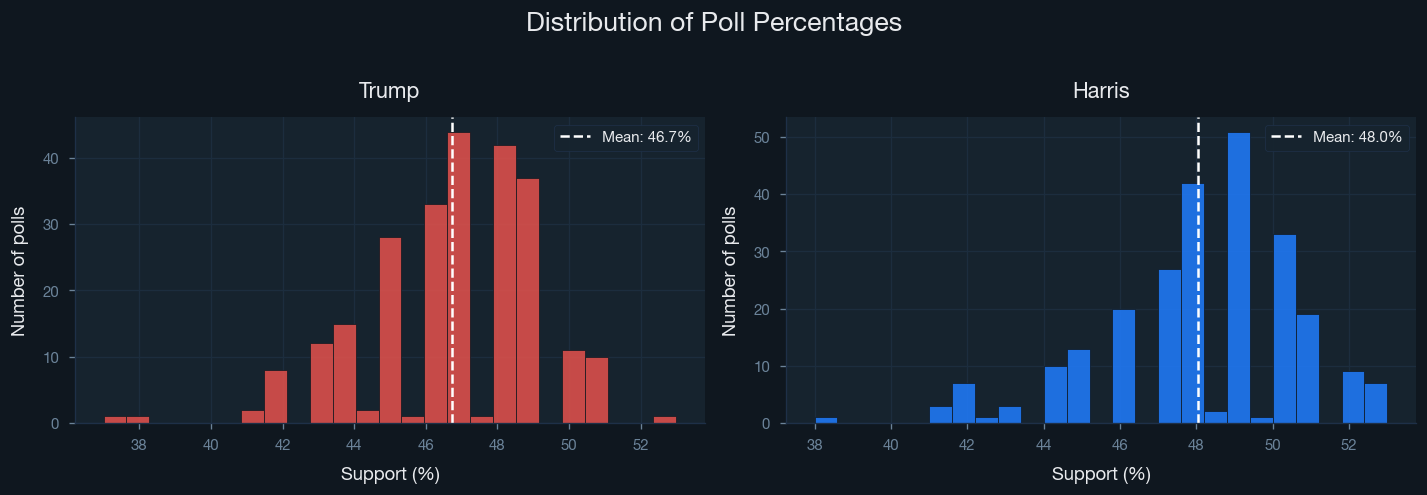

In [24]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 4),
                       title='Distribution of Poll Percentages')

for ax, col, color in zip(axes, ['Trump', 'Harris'], [REPUBLICAN, DEMOCRAT]):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.85, edgecolor=BG_DARK)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}%')
    style_ax(ax, xlabel='Support (%)', ylabel='Number of polls', title=col, grid_axis='y')
    ax.legend()

plt.tight_layout()
plt.show()

**What we see:**
- Both distributions are roughly **bell-shaped**, centred around 47% (Trump) and 48% (Harris).
- The spread is about ±3–4 pp, consistent with typical polling uncertainty.
- The distributions overlap almost entirely — reflecting just how close the race was.
- A small tail of polls shows Trump above 50% (mainly early Biden-era polls) and Harris above 50% (post-debate polls).

### 3.4 Monthly averages

Aggregating by month removes within-month noise and makes it easy to see the
overall trajectory of the race at a glance. Each bar is the mean of all polls
conducted in that calendar month.

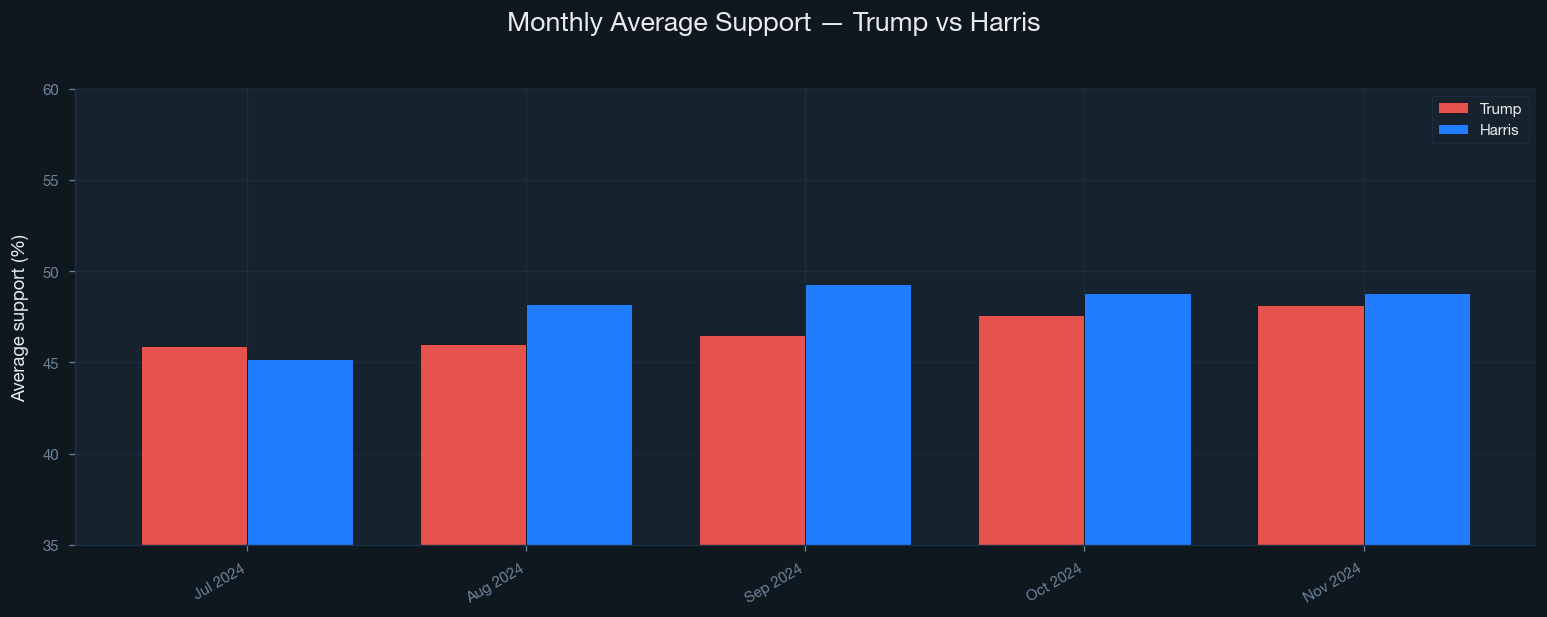

In [25]:
df_monthly = (
    df.set_index('Date')[['Trump', 'Harris']]
      .resample('ME').mean()
      .dropna()
)
labels = df_monthly.index.strftime('%b %Y')
x, w = np.arange(len(labels)), 0.38

fig, ax = styled_fig(figsize=(13, 5), title='Monthly Average Support — Trump vs Harris')
ax.bar(x - w/2, df_monthly['Trump'],  w, color=REPUBLICAN, label='Trump',  edgecolor=BG_DARK)
ax.bar(x + w/2, df_monthly['Harris'], w, color=DEMOCRAT,   label='Harris', edgecolor=BG_DARK)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', color=TEXT_MUTED)
ax.set_ylim(35, 60)
style_ax(ax, ylabel='Average support (%)', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

**What we see:**
- **June–July**: Trump clearly ahead (Biden era). Note that June and early July polls still have Biden as the opponent, so Trump's advantage here partly reflects Biden's weakness rather than Trump's strength.
- **August**: The Harris bump is visible — Harris overtakes Trump for the first time in monthly averages.
- **September–October**: Harris maintains a narrow lead. The gap stays within 1–2 pp.
- **November**: The small sample of final polls (mostly the last few days before election day) shows the race still essentially tied.

### 3.5 Average margin per pollster

**Pollster house effects** are systematic biases where a particular polling firm consistently
shows one candidate doing better than the average of all other polls. This can happen due to
differences in methodology (e.g. who they classify as a 'likely voter'), question wording, or
weighting choices.

We show only pollsters who conducted at least **3 polls** in our dataset, so the average is
based on enough data points to be meaningful.

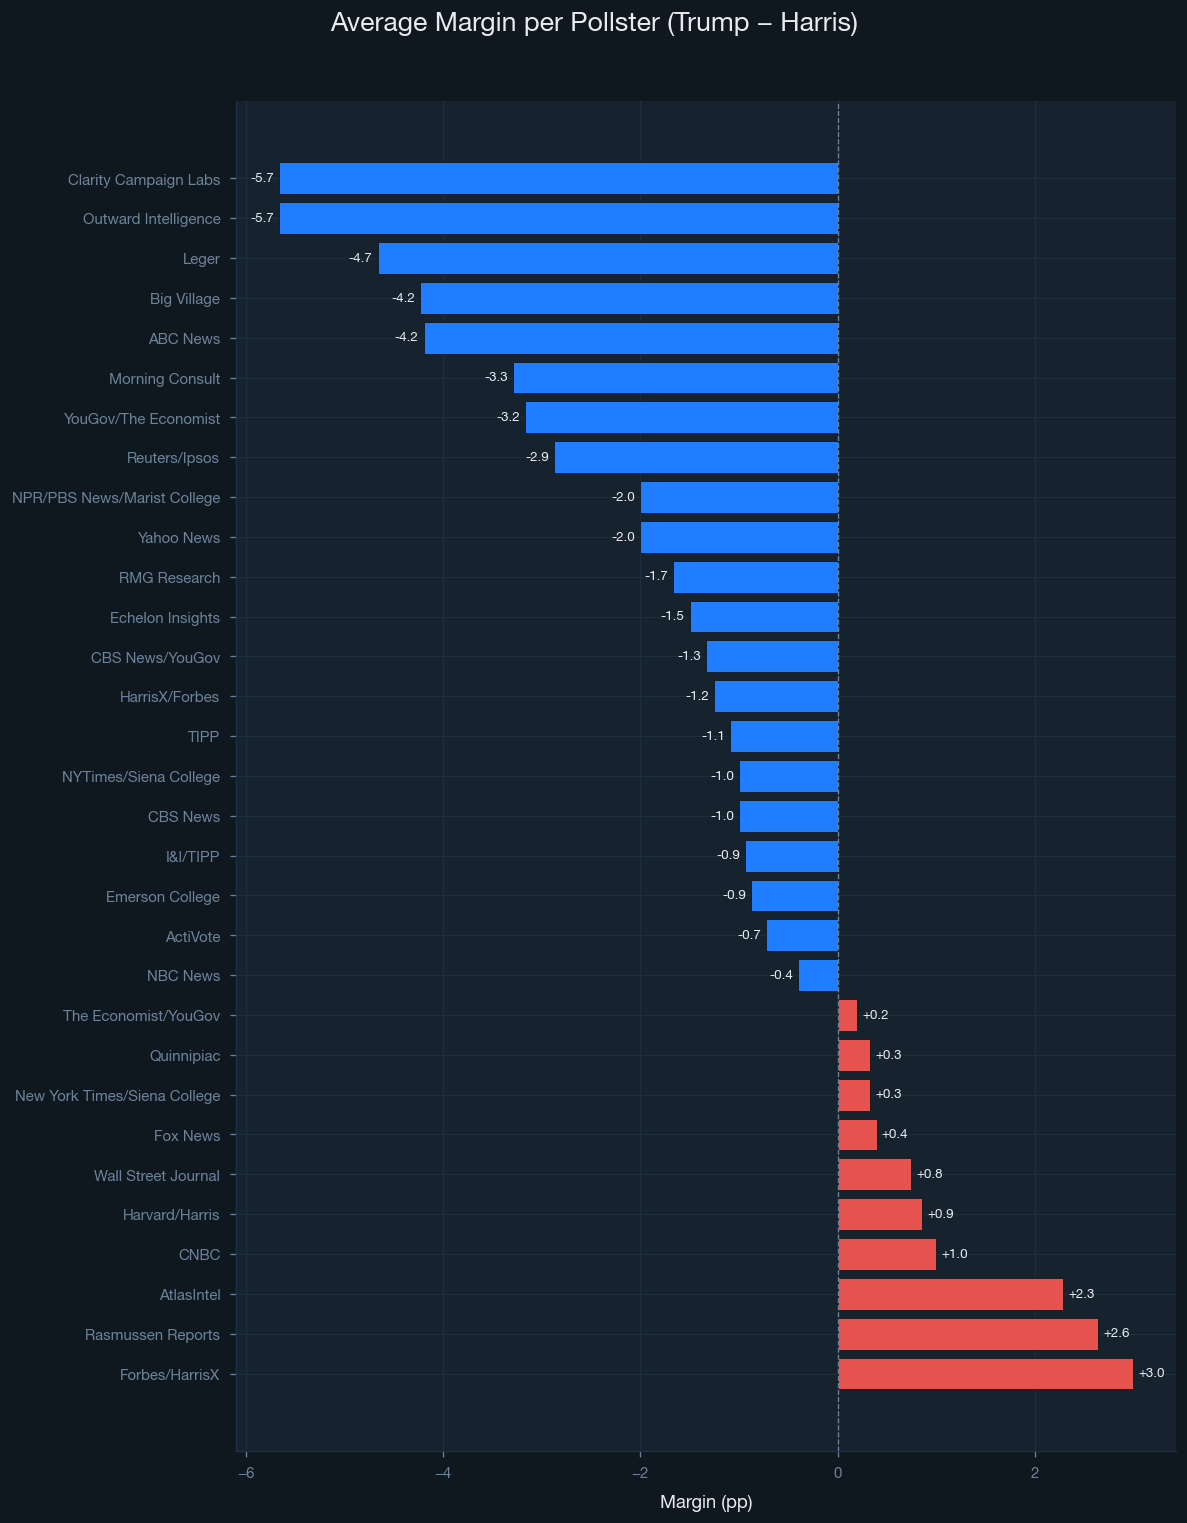

In [26]:
if 'Pollster' in df.columns:
    import re
    df['Pollster_clean'] = df['Pollster'].astype(str).apply(
        lambda s: re.sub(r'\[.*?\]', '', s).strip()
    )
    counts = df['Pollster_clean'].value_counts()
    top = counts[counts >= 3].index
    stats = (
        df[df['Pollster_clean'].isin(top)]
        .groupby('Pollster_clean')[['Trump', 'Harris', 'Margin']]
        .mean()
        .sort_values('Margin', ascending=False)
    )
    colors = [REPUBLICAN if m >= 0 else DEMOCRAT for m in stats['Margin']]
    fig, ax = styled_fig(figsize=(10, max(4, len(stats) * 0.4)),
                         title='Average Margin per Pollster (Trump − Harris)')
    bars = ax.barh(stats.index, stats['Margin'], color=colors, edgecolor=BG_DARK)
    ax.axvline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, stats['Margin']):
        xpos = val + 0.05 if val >= 0 else val - 0.05
        ha = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha=ha,
                color=TEXT_PRIMARY, fontsize=8)
    style_ax(ax, xlabel='Margin (pp)', grid_axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('No Pollster column available.')

**What we see:**
- There is clear **pollster variance**: some firms consistently show Trump ahead, others consistently show Harris ahead — even when measuring the same underlying population at the same point in time.
- Republican-leaning pollsters (e.g. Rasmussen, Trafalgar) tend to produce Trump-friendly results; university and academic pollsters tend to show Harris slightly ahead.
- This is why poll aggregation matters: no single poll should be taken at face value, and house effects need to be accounted for in any serious model.
- For our basetable we use the **aggregate rolling average** rather than individual polls, which averages out most of this house-effect noise.

## 4. Summary

### Key findings

| Finding | Detail |
|---|---|
| Harris polling lead | Harris averaged 47.9% vs Trump's 46.7% — a −1.2 pp margin across all polls |
| Polls Harris led | 151 of 256 polls (59%) |
| Biggest single event | Biden withdrawal (Jul 21): Trump margin swung ~6 pp toward Harris within days |
| Race dynamic | Effectively a statistical tie from August onward; never more than ~3 pp apart |
| Pollster variance | Large house effects visible — aggregation is necessary |

### Features for the basetable

| Feature | Description |
|---|---|
| `poll_trump` | Trump support in most recent poll(s) |
| `poll_harris` | Harris support in most recent poll(s) |
| `poll_margin` | Trump − Harris margin (signed) |
| `poll_trump_7d` | 7-day rolling average Trump support |
| `poll_harris_7d` | 7-day rolling average Harris support |

In [27]:
avg_margin = df['Margin'].mean()
leader = 'Trump' if avg_margin > 0 else 'Harris'

print('=' * 48)
print('  SUMMARY — WIKIPEDIA POLLS 2024')
print('=' * 48)
print(f'  Polls analysed            : {len(df)}')
print(f'  Date range                : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Average Trump support     : {df["Trump"].mean():.2f}%')
print(f'  Average Harris support    : {df["Harris"].mean():.2f}%')
print(f'  Average margin (T − H)    : {avg_margin:+.2f} pp  ({leader} leads on average)')
print(f'  Polls where Trump leads   : {(df["Margin"] > 0).sum()}')
print(f'  Polls where Harris leads  : {(df["Margin"] < 0).sum()}')
print(f'  Tied polls                : {(df["Margin"] == 0).sum()}')
print('=' * 48)

  SUMMARY — WIKIPEDIA POLLS 2024
  Polls analysed            : 249
  Date range                : 2024-07-06 → 2024-11-04
  Average Trump support     : 46.74%
  Average Harris support    : 48.03%
  Average margin (T − H)    : -1.29 pp  (Harris leads on average)
  Polls where Trump leads   : 76
  Polls where Harris leads  : 151
  Tied polls                : 22
